In [1]:
import torch
import torch.nn as nn

import torch_geometric as tg
import torch_geometric.utils as tgu
import torch_geometric.nn as tgnn
import matplotlib.pyplot as plt

import numpy as np
from sklearn.preprocessing import OneHotEncoder

In [2]:
! ls sequences/

data


In [3]:
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print(DEVICE)

cuda


## Notes from graphcast
 - there are multiple layers of nodes -> some nodes propagate information to more distant nodes
 - loss function takes into account multiple factors - e.g. sample density
 - autoregressive training 
   - model is trained using fix interval
   - to predict more distant (in time) points then previous prediction of a model is used
   - predicting 10 day ahead tends to have large overfitting
 - gnn was selected because weather function is the same in every place of the globe

In [4]:
import sys
sys.path.append('sequences')

In [5]:
import data.d1 as dataset_module

In [6]:
samples, test_names, units = dataset_module.load_dataset()
samples = [*filter(lambda x: len(x)>10, samples)]
print([len(i) for i in samples])

[35, 31, 43, 40, 43, 40]


/workspace/sequences/data/d1/__init__.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['date'] = data.apply(lambda x: dateparse(x['data']), axis=1)


In [7]:
name_enc = OneHotEncoder()
unit_enc = OneHotEncoder()

name_enc.fit([[i] for i in test_names])
unit_enc.fit([[i] for i in units.keys()])


def scale_value(unit_name, value, units):
    min, max = units[unit_name]
    if np.isnan(max):
        max = 6*min+.000001
    return (value - min) / (max-min)

def reverse_scale_value(unit_name, value, units):
    min, max = units[unit_name]
    if np.isnan(max):
        max = 6*min+.000001
    return value * (max-min) + min

def get_sample(samples, units, inclusion_prob=0.5):
    sample_idx = np.random.randint(0, len(samples))
    sample = samples[sample_idx]

    nof_tests = len(sample)

    fully_connected_adj = torch.ones(nof_tests, nof_tests)
    fully_connected = tgu.dense_to_sparse(fully_connected_adj)[0]

    names_encoded = name_enc.transform([[_sample[0]] for _sample in sample]).toarray()
    units_encoded = unit_enc.transform([[_sample[2]] for _sample in sample]).toarray()

    model_input = []
    model_output = []
    is_included = np.random.random(nof_tests) < inclusion_prob
    for idx, included in zip(range(nof_tests), is_included):
        model_input.append(np.concatenate([
            names_encoded[idx], #test_name_encoded
            units_encoded[idx], # unit uncoded
            np.array([included*1.0]),
            np.array([scale_value(sample[idx][2], sample[idx][1], units) * included])
        ]))

        model_output.append(np.concatenate([
            names_encoded[idx], #test_name_encoded
            units_encoded[idx], # unit uncoded
            np.array([1.0]),
            np.array([scale_value(sample[idx][2], sample[idx][1], units)]) # scaled_value
        ]))
    return tg.data.Data(
        x=torch.tensor(np.array(model_input),dtype=torch.float32),
        edge_index=fully_connected,
        y=torch.tensor(np.array(model_output), dtype=torch.float32),
    )
    # return tg.data.Data(
    #     x=torch.tensor(sample, dtype=torch.float32, requires_grad=False),
    #     edge_index=torch.tensor(fully_connected, dtype=torch.int64, requires_grad=False),
    #     y=torch.tensor(sample_dt, dtype=torch.float32, requires_grad=False)
    # )

In [8]:
s = get_sample(samples, units)

In [20]:
feature_vector_len = 32
edge_vector_len = 200

class AutoEncoder(nn.Module):
    def __init__(self, input_size, hidden_size=8, input_size_expander=4):
        nn.Module.__init__(self)
        
        # Set the number of hidden units
        self.num_hidden = hidden_size
        
        # Define the encoder part of the autoencoder
        self.encoder = nn.Sequential(
            nn.Linear(input_size, input_size_expander*input_size),  # input size: 784, output size: 256
            nn.GELU(),  # apply the ReLU activation function
            nn.Linear(input_size_expander*input_size, self.num_hidden),  # input size: 256, output size: num_hidden
            nn.GELU(),  # apply the ReLU activation function
        )
        
        # Define the decoder part of the autoencoder
        self.decoder = nn.Sequential(
            nn.Linear(self.num_hidden, input_size_expander*input_size),  # input size: num_hidden, output size: 256
            nn.GELU(),  # apply the ReLU activation function
            nn.Linear(input_size_expander*input_size, input_size_expander*input_size),  # input size: num_hidden, output size: 256
            nn.GELU(),  # apply the ReLU activation function
            nn.Linear(input_size_expander*input_size, input_size),  # input size: 256, output size: 784
        )

    def forward(self, x):
        # Pass the input through the encoder
        encoded = self.encoder(x)
        # Pass the encoded representation through the decoder
        decoded = self.decoder(encoded)
        # Return both the encoded representation and the reconstructed output
        return encoded, decoded

In [21]:
ae = AutoEncoder(95, hidden_size=feature_vector_len, input_size_expander=4)
ae_dataset = torch.cat([get_sample(samples,units).x for _ in range(4096)])
batch_size = 64
num_epochs = 4

optimizer = torch.optim.Adam(ae.parameters(), lr=1e-3)

# Define the loss function
criterion = nn.MSELoss()

# Set the device to GPU if available, otherwise use CPU
ae.to(DEVICE)

# Create a DataLoader to handle batching of the training data
train_loader = torch.utils.data.DataLoader(
    ae_dataset, batch_size=64, shuffle=True
)

for epoch in range(num_epochs):
    total_loss = 0.0
    for batch_idx, data in enumerate(train_loader):
        # Get a batch of training data and move it to the device
        data = data.to(DEVICE)

        # Forward pass
        encoded, decoded = ae(data)

        # Compute the loss and perform backpropagation
        loss = criterion(decoded, data)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Update the running loss
        total_loss += loss.item() * data.size(0)

    # Print the epoch loss
    epoch_loss = total_loss / len(train_loader.dataset)
    print(
        "Epoch {}/{}: loss={:.6f}".format(epoch + 1, num_epochs, epoch_loss)
    )

Epoch 1/4: loss=0.001100
Epoch 2/4: loss=0.000017
Epoch 3/4: loss=0.000017
Epoch 4/4: loss=0.000017


In [22]:
sample = get_sample(samples, units)
ae.decoder(
    ae.encoder(sample.x.to(DEVICE))
)

tensor([[-1.7065e-04, -3.6628e-03,  5.4803e-04,  ..., -2.5439e-03,
          9.9411e-01, -1.1905e-01],
        [-1.2106e-03,  2.7716e-03,  1.2621e-04,  ..., -1.7645e-03,
          2.9047e-04,  3.2430e-03],
        [-2.7364e-03,  1.8323e-03,  2.5262e-03,  ...,  7.8454e-04,
          1.7980e-02,  6.3850e-03],
        ...,
        [ 1.2718e-04, -1.0219e-03, -2.6349e-04,  ..., -1.7295e-03,
          9.8581e-01,  2.4295e-02],
        [ 3.6055e-03, -4.5020e-03, -2.4802e-03,  ..., -6.2577e-05,
          9.8048e-01, -1.7808e-01],
        [ 1.0683e-03, -7.0422e-04, -1.3424e-03,  ...,  6.5237e-04,
          1.0153e+00, -1.7613e-01]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [34]:
# x_cord, y_cord, time
# time_embed 
ae.decoder.requires_grad_(False)
ae.encoder.requires_grad_(False)

class gnn_model(nn.Module):
    def __init__(self):
        nn.Module.__init__(self)

        self.fe = ae.encoder
        self.fd = ae.decoder

        encoder_layer = nn.TransformerEncoderLayer(d_model=feature_vector_len, nhead=4)
        self.l1 = nn.TransformerEncoder(encoder_layer, num_layers=3)

    def forward(self, data):
        nodes = data.x

        encoded_features = self.fe(nodes).reshape([-1, 30, feature_vector_len])

        g_output = self.l1(encoded_features)
        decoded = self.fd(g_output).flatten(end_dim=1)

        return decoded[:,-1:]



In [36]:
model = gnn_model()
model.to(DEVICE)
sample.x = sample.x[:30]
with torch.no_grad():
    print(model(sample.to(DEVICE)).shape)

torch.Size([30, 1])


In [41]:
NUM_TR_STEPS = 80
BATCH_SIZE = 32
model.training_mode = True
loss_t_0 = []
loss_t_dt = []
optimizer = torch.optim.AdamW(model.parameters(),lr=2e-3,)
loss_fn = nn.MSELoss()
ss = [s[:30] for s in samples]
_data = [get_sample(ss, units) for _ in range(4096)]
dl = tg.data.DataLoader(_data, batch_size=2)

print('starting training')
for i in range(NUM_TR_STEPS):
    for idx, batch in enumerate(dl):
        if batch.x.shape[0] < 30:
            continue
        print(f"IDX: {idx}", end='\r')
        batch = batch.to(DEVICE)
        y_hat = model(batch)

        loss = loss_fn(batch.y[:,-1], y_hat[:,-1])

        # check if this is correct place for zero grad
        optimizer.zero_grad()
        loss.backward()

        optimizer.step()

        if idx%8 == 0 and i>=2:
            l_dt = loss.detach().cpu().item()
            loss_t_dt.append(l_dt)
            print(f"l_dt:{l_dt}")
        elif idx%256 == 0 and i<2:
            l_dt = loss.detach().cpu().item()
            loss_t_dt.append(l_dt)
            print(f"l_dt:{l_dt}")

    if i == 1:
        print('generating new ds')
        dl = tg.data.DataLoader(_data, batch_size=BATCH_SIZE)
    



/opt/conda/lib/python3.11/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


starting training
l_dt:0.0018247341504320502
l_dt:0.002438143128529191
l_dt:0.002174749504774809
l_dt:0.004156662616878748
l_dt:0.0016401531174778938
l_dt:0.0011100487317889929
l_dt:0.0009623460937291384
l_dt:0.0019074097508564591
l_dt:0.0008613954996690154
l_dt:0.0012115470599383116
l_dt:0.000582869746722281
l_dt:0.0031520482152700424
l_dt:0.0018095485866069794
l_dt:0.004135249648243189
l_dt:0.0006110543035902083
l_dt:0.0011078912066295743
generating new ds
l_dt:0.0012403718428686261
l_dt:0.0012391118798404932
l_dt:0.0009732434409670532
l_dt:0.0009965099161490798
l_dt:0.001164365210570395
l_dt:0.001030168728902936
l_dt:0.0010970247676596045
l_dt:0.0011847640853375196
l_dt:0.0012098437873646617
l_dt:0.0011312778806313872
l_dt:0.0009486518683843315
l_dt:0.0014032517792657018
l_dt:0.0009103348129428923
l_dt:0.0011318702017888427
l_dt:0.0012658785562962294
l_dt:0.0017558898543938994
l_dt:0.0011960448464378715
l_dt:0.001148874987848103
l_dt:0.0009069885709322989
l_dt:0.0009730641031637788


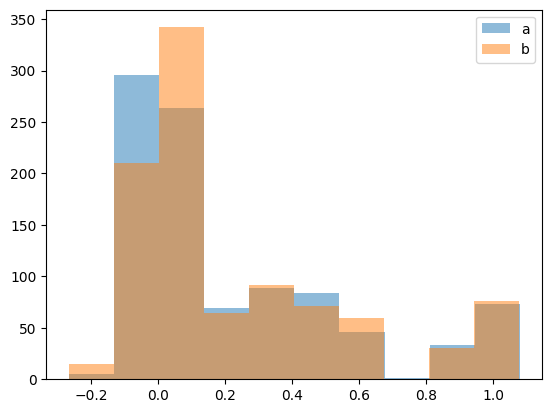

In [42]:
plt.hist(y_hat.detach().cpu().numpy().flatten(),alpha=0.5, label='a')
plt.hist(batch.y[:,-1].cpu().numpy().flatten(),alpha=0.5, label='b')
plt.legend()
plt.show()

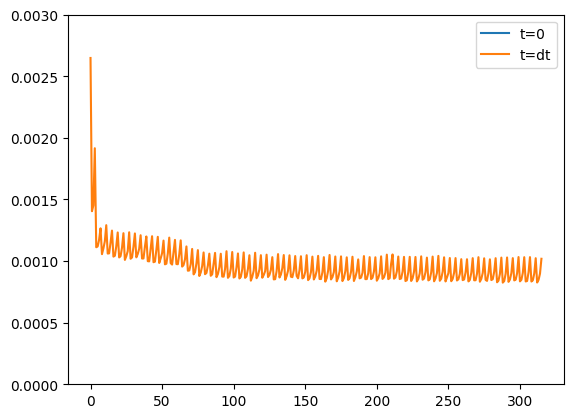

In [47]:
mean_over = 4
t0 = np.array([torch.mean(x).item() for x in loss_t_0])
t0_mean = t0[t0.shape[0]%mean_over:].reshape([-1,mean_over]).mean(axis=1)

t_dt = np.array(loss_t_dt)
t_dt_mean = t_dt[t_dt.shape[0]%mean_over:].reshape([-1,mean_over]).mean(axis=1)

plt.plot(t0_mean, label='t=0')
plt.plot(t_dt_mean, label='t=dt')
plt.legend()
plt.ylim(0.0,.003)
plt.show()

/tmp/ipykernel_172/4118403958.py:14: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3683.)
  l_dt = ((sample.y[:,-1] - y_hat[:,-1])**2).T


MSE: 0.0020428786519914865
MSE: 0.002133576897904277
MSE: 0.001491845236159861


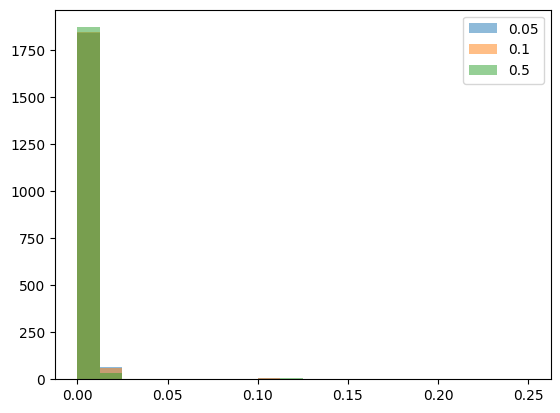

RMSE: 0.02170351706445217
RMSE: 0.021390311419963837
RMSE: 0.017275067046284676


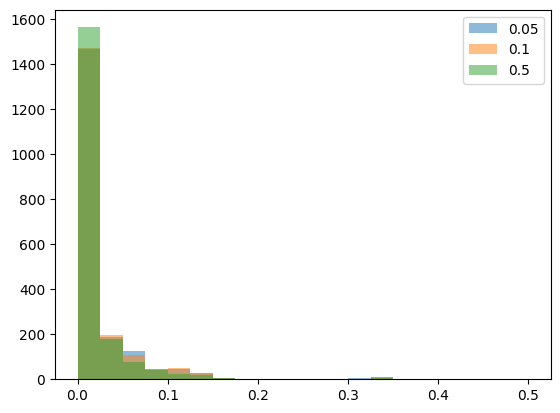

In [49]:
NUM_TEST_STEPS = 64
res_dict = {}
model.training_mode = False
with torch.no_grad():
    for inc_prob in [.05,.1,.5]:
        loss_te_dt = []
        for i in range(NUM_TEST_STEPS):
            sample = get_sample(ss, units,inclusion_prob=inc_prob).to(DEVICE)

            y_hat = model(
                sample
            )

            l_dt = ((sample.y[:,-1] - y_hat[:,-1])**2).T
            loss_te_dt.append(l_dt.detach())
        res_dict[inc_prob] = torch.cat(loss_te_dt).cpu().numpy()

for label, part_res in res_dict.items():
    plt.hist(part_res,range=(0,.25), alpha=0.5, label=str(label), bins=20)
    print(f"MSE: {np.mean(part_res)}")
plt.legend()
plt.show()

for label, part_res in res_dict.items():
    plt.hist(part_res**0.5,range=(0,.5), alpha=0.5, label=str(label), bins=20)
    print(f"RMSE: {np.mean(part_res**0.5)}")
plt.legend()
plt.show()

MSE: 0.17092175781726837
MSE: 0.15686503052711487
MSE: 0.14559249579906464
MSE: 0.08899862319231033


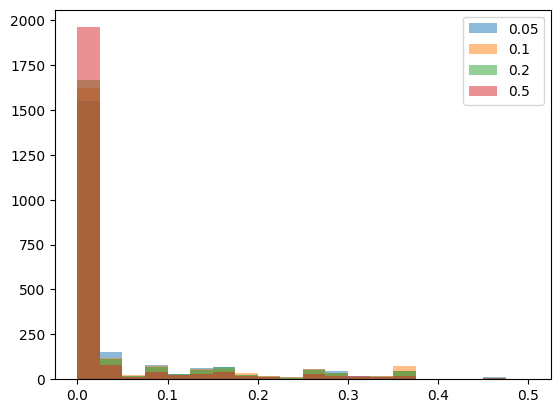

RMSE: 0.2303587794303894
RMSE: 0.21928653120994568
RMSE: 0.19718784093856812
RMSE: 0.11889763921499252


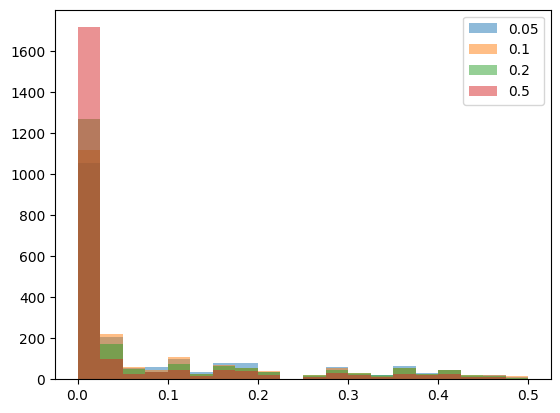

In [67]:
NUM_TEST_STEPS = 64
res_dict = {}

with torch.no_grad():
    for inc_prob in [.05,.1,.2,.5]:
        loss_te_dt = []
        for i in range(NUM_TEST_STEPS):
            sample = get_sample(samples, units,inclusion_prob=inc_prob)

            l_dt = ((sample.y[:,-1] - sample.x[:,-1])**2).T
            loss_te_dt.append(l_dt.detach())
        res_dict[inc_prob] = torch.cat(loss_te_dt).cpu().numpy()

for label, part_res in res_dict.items():
    plt.hist(part_res,range=(0,.5), alpha=0.5, label=str(label), bins=20)
    print(f"MSE: {np.mean(part_res)}")
plt.legend()
plt.show()

for label, part_res in res_dict.items():
    plt.hist(part_res**0.5,range=(0,.5), alpha=0.5, label=str(label), bins=20)
    print(f"RMSE: {np.mean(part_res**0.5)}")
plt.legend()
plt.show()

In [51]:
sample = get_sample(ss, units=units, inclusion_prob=0.05)

In [77]:
preds = model(sample.to(DEVICE)).detach().cpu()

In [ ]:
for name, unit, pred, tr in zip(
    name_enc.inverse_transform(sample.x[:,:72].cpu().detach()),
    unit_enc.inverse_transform(sample.x[:,72:-2].cpu().detach()),
    preds,
    sample.y[:,-1]
):
    # tr refers to true value
    print(f"{reverse_scale_value(unit.item(), pred.item(), units):0.2f} {name.item()} || {reverse_scale_value(unit.item(), tr.cpu().item(), units):0.2f} {name.item()} // {unit.item()}" )